In [14]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
df = pd.read_csv('E:\Data Analyst Projects\Customer-Churn-Project\data\Advanced_retail_analytics.csv')
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,total_revenue,churn_risk_score,revenue_per_frequency_day,segment_id,customer_segment,churn_category
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Venmo,Fortnightly,Middle Aged,14,742,1.92,3.79,0,Loyal High-Spenders,Low Risk
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Cash,Fortnightly,Young Adult,14,128,1.92,4.57,0,Loyal High-Spenders,Low Risk
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Credit Card,Weekly,Middle Aged,7,1679,0.96,10.43,0,Loyal High-Spenders,Low Risk
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,PayPal,Weekly,Young Adult,7,4410,0.96,12.86,2,Budget Occasional,Low Risk
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,PayPal,Annually,Middle Aged,365,1519,50.00,0.13,3,Young Trendsetters,Medium Risk


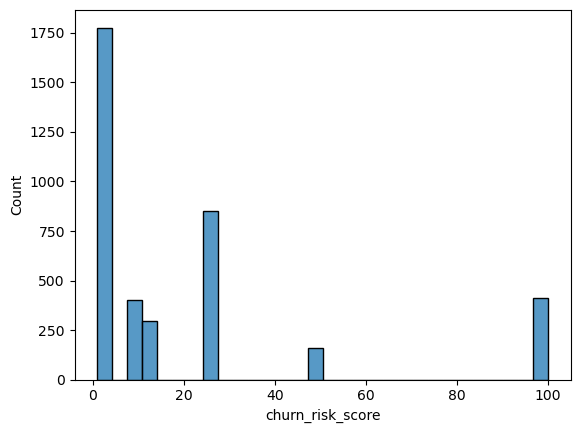

In [15]:
# 1  Churn Distribution
sns.histplot(df['churn_risk_score'], bins = 30)
plt.show()

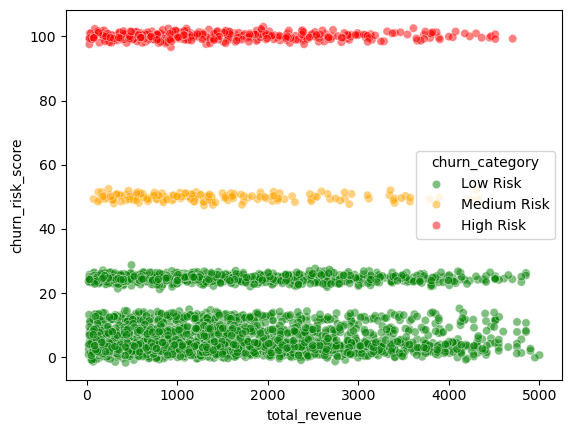

In [16]:
# 2 compare churn vs revenue 
# customizing colors 
palette= {
    'High Risk':'red',
    'Medium Risk':'orange',
    'Low Risk':'green'
}
sns.scatterplot( x='total_revenue',y=df['churn_risk_score'] + np.random.normal(0, 1, len(df)), hue='churn_category', data=df,  alpha=0.5,  palette = palette )
plt.show()

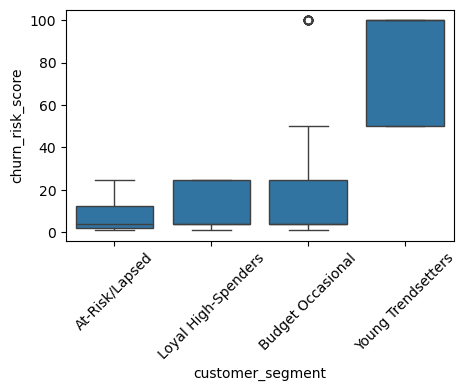

In [17]:
# 3 churn by segments 
plt.figure(figsize=(5,3))
order = df.groupby('customer_segment')['churn_risk_score'].mean().sort_values().index
sns.boxplot(x = 'customer_segment', y='churn_risk_score', data=df, order=order)
plt.xticks(rotation=45)
plt.show()

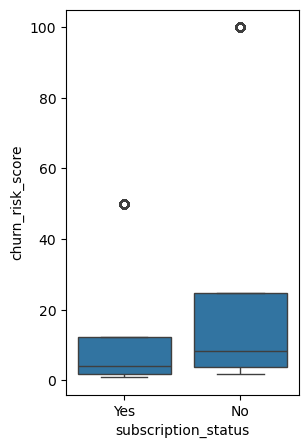

In [18]:
# 4 Churn vs Subscription
plt.figure(figsize=(3,5))
sns.boxplot(x='subscription_status', y='churn_risk_score', data=df)
plt.show()

# Create Some KPI Matrics

In [19]:
#  1. Total Customers
total_customers = df['customer_id'].nunique()
total_customers

3900

In [20]:
# 2. High Risk Customers
high_risk = df[df['churn_category'] == "High Risk"].shape[0]
high_risk

412

In [21]:
# 3. Average Revenue
avg_revenue = df['total_revenue'].mean()
avg_revenue

np.float64(1517.876923076923)

In [22]:
# 4. Retention Indicator
retained = df[df['churn_category'] == "Low Risk"].shape[0]
retained

3328

# Advance Analysis

In [23]:
# A. High-Risk Customer Profile
df[df['churn_category']=="High Risk"].describe()

,customer_id,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days,total_revenue,churn_risk_score,revenue_per_frequency_day,segment_id
count,412.000000,412.000000,412.000000,412.000000,412.000000,412.0,412.000000,412.0,412.000000,412.000000
mean,2536.963592,45.516990,60.696602,3.790049,24.543689,365.0,1482.592233,100.0,0.166044,2.944175
std,815.347373,15.604984,24.209602,0.682505,14.207895,0.0,1086.776836,0.0,0.066502,0.229863
min,1056.000000,18.000000,20.000000,2.500000,1.000000,365.0,30.000000,100.0,0.050000,2.000000
25%,1842.250000,32.000000,38.000000,3.300000,13.000000,365.0,609.500000,100.0,0.100000,3.000000
50%,2552.500000,46.000000,61.000000,3.800000,24.000000,365.0,1215.500000,100.0,0.170000,3.000000
75%,3249.000000,59.000000,82.250000,4.400000,36.000000,365.0,2208.750000,100.0,0.222500,3.000000
max,3891.000000,70.000000,100.000000,5.000000,50.000000,365.0,4704.000000,100.0,0.270000,3.000000


In [24]:
# B. Revenue at Risk
revenue_risk =df[df['churn_category']=="High Risk"]['total_revenue'].sum()
revenue_risk

np.int64(610828)

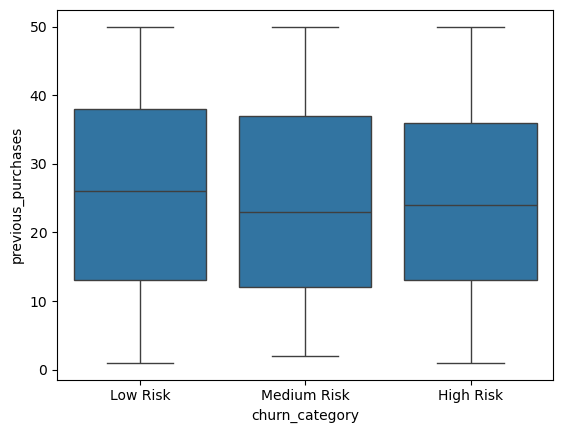

In [25]:
# C. Behavior Patterns
sns.boxplot(x='churn_category', y='previous_purchases', data=df)
plt.show()

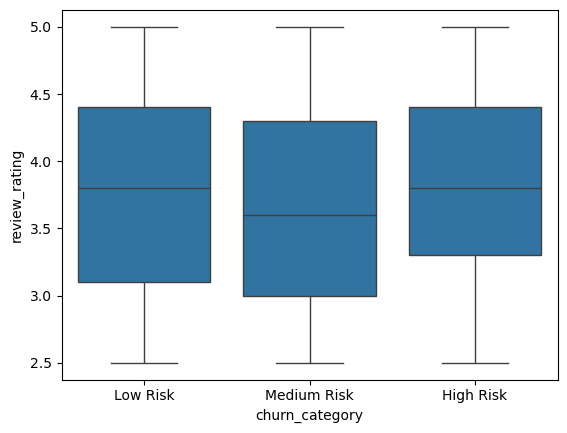

In [26]:
# D. Lower ratings → higher churn
sns.boxplot(x='churn_category', y='review_rating', data=df)
plt.show()

In [27]:
df

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,total_revenue,churn_risk_score,revenue_per_frequency_day,segment_id,customer_segment,churn_category
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Venmo,Fortnightly,Middle Aged,14,742,1.92,3.79,0,Loyal High-Spenders,Low Risk
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Cash,Fortnightly,Young Adult,14,128,1.92,4.57,0,Loyal High-Spenders,Low Risk
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Credit Card,Weekly,Middle Aged,7,1679,0.96,10.43,0,Loyal High-Spenders,Low Risk
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,PayPal,Weekly,Young Adult,7,4410,0.96,12.86,2,Budget Occasional,Low Risk
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,PayPal,Annually,Middle Aged,365,1519,50.00,0.13,3,Young Trendsetters,Medium Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,Venmo,Weekly,Adult,7,896,1.92,4.00,1,At-Risk/Lapsed,Low Risk
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,Bank Transfer,Bi-Weekly,Middle Aged,14,2009,3.84,3.50,1,At-Risk/Lapsed,Low Risk
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,Venmo,Quarterly,Middle Aged,90,792,24.66,0.37,1,At-Risk/Lapsed,Low Risk
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,Venmo,Weekly,Adult,7,1848,1.92,11.00,2,Budget Occasional,Low Risk
